# Cheat Sheet: Data Types, Distributions & Resampling in Python

Quick-reference snippets for every concept in this lab. Each section is
self-contained and runnable — copy/paste what you need.


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import permutations, combinations


## 1. Data types — quick decision guide

| Ask yourself... | If yes | Type |
|---|---|---|
| Only equal/not-equal makes sense? | yes | **Nominal** |
| Can I order the categories? | yes | **Ordinal** |
| Can I add/subtract, but zero is arbitrary? | yes | **Interval** |
| Can I add/subtract/multiply/divide, and zero means "none"? | yes | **Ratio** |

- Nominal/ordinal → visualize with `plt.bar(labels, counts)`
- Interval/ratio → visualize with `plt.hist(values, bins=...)`


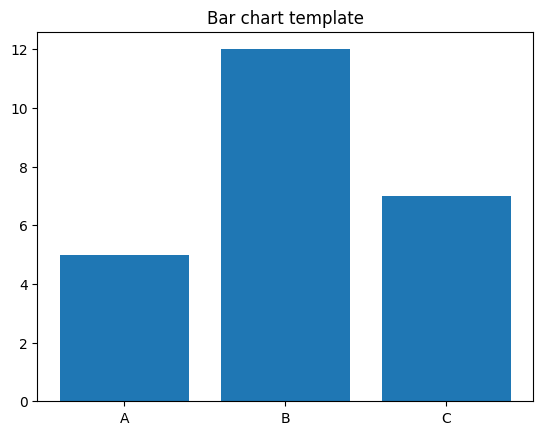

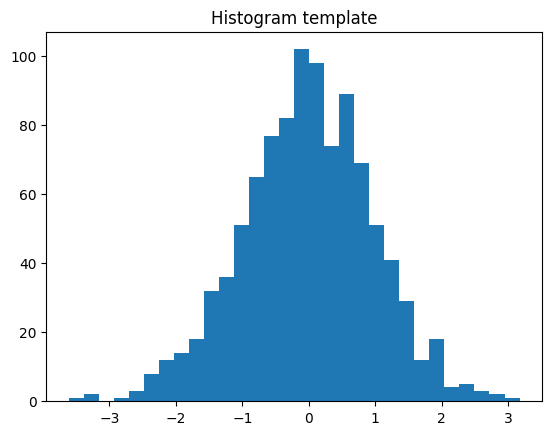

In [2]:
# Bar chart (nominal / ordinal)
labels, counts = ['A', 'B', 'C'], [5, 12, 7]
plt.bar(labels, counts); plt.title('Bar chart template'); plt.show()

# Histogram (interval / ratio)
data = np.random.randn(1000)
plt.hist(data, bins=30); plt.title('Histogram template'); plt.show()


## 2. Descriptive statistics — formula & code side by side

| Stat | Formula | Code |
|---|---|---|
| Mean | Σx / N | `np.mean(x)` |
| Median | middle value (sorted) | `np.median(x)` |
| Mode | most frequent value | `stats.mode(x, keepdims=True)` |
| Variance (sample) | Σ(x−x̄)² / (N−1) | `np.var(x, ddof=1)` |
| Std dev (sample) | √variance | `np.std(x, ddof=1)` |
| Range | max − min | `np.max(x) - np.min(x)` |
| Quartiles | sorted data cut into 4 | `np.quantile(x, [.25,.5,.75])` |
| IQR | Q3 − Q1 | `stats.iqr(x)` |
| Tukey fences | Q1−k·IQR , Q3+k·IQR (k=1.5) | see snippet below |
| Skewness | asymmetry measure | `stats.skew(x)` |
| Kurtosis | tail-heaviness vs. normal | `stats.kurtosis(x)` |

**Gotcha:** `np.var`/`np.std` default to `ddof=0` (population formula). Use
`ddof=1` for a sample meant to estimate a population parameter.


In [3]:
x = [85, 99, 70, 71, 86, 88, 94]

q1, q2, q3 = np.quantile(x, [0.25, 0.5, 0.75])
iqr = q3 - q1
k = 1.5
lower_fence, upper_fence = q1 - k*iqr, q3 + k*iqr
outliers = [v for v in x if v < lower_fence or v > upper_fence]

print(f"Q1={q1}, Median={q2}, Q3={q3}, IQR={iqr}")
print(f"Tukey fences: [{lower_fence:.2f}, {upper_fence:.2f}]  Outliers: {outliers}")


Q1=78.0, Median=86.0, Q3=91.0, IQR=13.0
Tukey fences: [58.50, 110.50]  Outliers: []


## 3. Normal distribution / Empirical Rule / CLT


In [4]:
# PDF / CDF of a normal distribution
mu, sigma = 0, 1
x_grid = np.linspace(-4, 4, 200)
pdf = stats.norm.pdf(x_grid, mu, sigma)
cdf = stats.norm.cdf(x_grid, mu, sigma)

# Probability a value falls in [a, b]
prob = stats.norm.cdf(1, mu, sigma) - stats.norm.cdf(-1, mu, sigma)
print(f"P(-1 < Z < 1) = {prob:.4f}  (Empirical Rule says ~0.683)")


P(-1 < Z < 1) = 0.6827  (Empirical Rule says ~0.683)


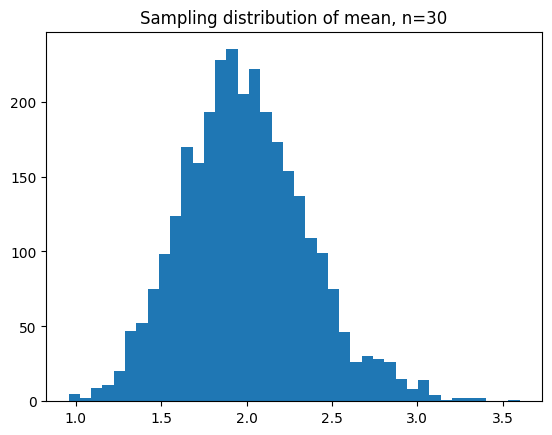

In [5]:
# CLT one-liner pattern: sampling distribution of the mean
population = np.random.exponential(scale=2.0, size=1_000_000)
n = 30
sample_means = [population[np.random.randint(0, len(population), n)].mean() for _ in range(3000)]
plt.hist(sample_means, bins=40); plt.title(f'Sampling distribution of mean, n={n}'); plt.show()


## 4. Bootstrapping — reusable snippets


In [6]:
def bootstrap_stat(sample, stat_fn=np.mean, n_replicas=10000, frac=1.0, replace=True, seed=None):
    '''Generic bootstrap: resample `sample` and apply `stat_fn` each time.'''
    rng = np.random.default_rng(seed)
    sample = np.asarray(sample)
    n = max(1, int(len(sample) * frac))
    return np.array([stat_fn(rng.choice(sample, size=n, replace=replace)) for _ in range(n_replicas)])

def bootstrap_ci(boot_dist, p=5):
    '''p = significance level in percent (5 -> 95% CI). Returns (lower, upper).'''
    return np.percentile(boot_dist, p/2), np.percentile(boot_dist, 100 - p/2)

# Example: bootstrap the mean AND the median
sample = np.random.gamma(shape=2, scale=2, size=50)
boot_mean = bootstrap_stat(sample, stat_fn=np.mean, seed=0)
boot_median = bootstrap_stat(sample, stat_fn=np.median, seed=0)
print("Mean 95% CI:  ", bootstrap_ci(boot_mean))
print("Median 95% CI:", bootstrap_ci(boot_median))


Mean 95% CI:   (np.float64(3.5977935499625535), np.float64(5.212095882287328))
Median 95% CI: (np.float64(2.6726936452010923), np.float64(4.716732146554866))


In [7]:
# Bootstrap a correlation coefficient (resample ROWS, keep pairs intact)
df = pd.DataFrame({'x': np.random.randn(100)})
df['y'] = 2*df['x'] + np.random.randn(100)*0.5

rng = np.random.default_rng(0)
boot_r = []
for _ in range(5000):
    idx = rng.choice(len(df), size=len(df), replace=True)
    r, _ = stats.pearsonr(df['x'].iloc[idx], df['y'].iloc[idx])
    boot_r.append(r)
boot_r = np.array(boot_r)
print("Bootstrap correlation 95% CI:", bootstrap_ci(boot_r))


Bootstrap correlation 95% CI: (np.float64(0.9413648156573547), np.float64(0.9754023274837453))


**Standard error from a bootstrap distribution:** `scipy.stats.sem(boot_dist)`
(this is the SE *of the bootstrap distribution*; it approximates the SE of the
original statistic).


## 5. Permutations, combinations, permutation testing


In [8]:
n, r = 10, 3
print("P(n,r) formula:", np.math.factorial(n)//np.math.factorial(n-r) if hasattr(np,'math')
      else __import__('math').factorial(n)//__import__('math').factorial(n-r))
print("len(list(permutations(range(n), r))):", len(list(permutations(range(n), r))))
print("C(n,r) formula:", __import__('math').comb(n, r))
print("len(list(combinations(range(n), r))):", len(list(combinations(range(n), r))))


P(n,r) formula: 720
len(list(permutations(range(n), r))): 720
C(n,r) formula: 120
len(list(combinations(range(n), r))): 120


In [9]:
def permutation_test(A, B, n_iter=10000, seed=None, alternative='two-sided'):
    '''Non-parametric test for difference in means. alternative: 'greater'|'less'|'two-sided' '''
    rng = np.random.default_rng(seed)
    A, B = np.asarray(A, dtype=float), np.asarray(B, dtype=float)
    observed = A.mean() - B.mean()
    pooled = np.concatenate([A, B]); n_a = len(A)
    diffs = np.empty(n_iter)
    for i in range(n_iter):
        rng.shuffle(pooled)
        diffs[i] = pooled[:n_a].mean() - pooled[n_a:].mean()
    if alternative == 'greater':
        p = np.mean(diffs >= observed)
    elif alternative == 'less':
        p = np.mean(diffs <= observed)
    else:
        p = np.mean(np.abs(diffs) >= abs(observed))
    return p, observed

p, obs = permutation_test([3,5,4], [43,41,56,78,54], n_iter=10000, seed=1, alternative='greater')
print(f"observed diff={obs:.2f}  p-value={p:.4f}")


observed diff=-50.40  p-value=1.0000


**Rule of thumb:** use `alternative='two-sided'` unless you have a strong
a-priori reason (decided *before* seeing the data) to expect the difference in
one specific direction.


## 6. Transformations


In [10]:
x = np.random.beta(1, 10, size=5000)  # right-skewed, x in (0, 1)

x_log   = np.log(x)          # requires x > 0
x_sqrt  = np.sqrt(x)         # requires x >= 0
x_cbrt  = np.cbrt(x)         # works for any real x (including negative)
x_log1p = np.log1p(x)        # log(1+x), safe when x can be 0

x_boxcox, best_lambda = stats.boxcox(x + 1e-9)   # requires x > 0; auto-picks lambda
print("Box-Cox lambda:", round(best_lambda, 3))

for name, arr in [('original', x), ('log', x_log), ('sqrt', x_sqrt),
                   ('cbrt', x_cbrt), ('log1p', x_log1p), ('boxcox', x_boxcox)]:
    print(f"{name:9s} skew={stats.skew(arr):+.3f}")


Box-Cox lambda: 0.298
original  skew=+1.533
log       skew=-1.171
sqrt      skew=+0.439
cbrt      skew=+0.031
log1p     skew=+1.289
boxcox    skew=-0.063


| Transform | Formula | Domain | Typical use |
|---|---|---|---|
| `log(x)` | ln(x) | x > 0 | strong right skew |
| `sqrt(x)` | x^0.5 | x ≥ 0 | moderate right skew, counts |
| `cbrt(x)` | x^(1/3) | any x | moderate skew, allows negatives/zero |
| `log1p(x)` | ln(1+x) | x > -1 | right skew with zeros present |
| `boxcox(x)` | (x^λ−1)/λ, auto λ | x > 0 | data-driven "best" power transform |

**Reversing a transform for interpretation:** `np.exp(x_log)`,
`x_sqrt**2`, `x_cbrt**3`, `np.expm1(x_log1p)`, `scipy.special.inv_boxcox(x_boxcox, best_lambda)`.


## 7. Quick sanity-check tests


In [11]:
sample = np.random.randn(300)

# Formal normality test (small/medium n; subsample if n is large)
stat, p_shapiro = stats.shapiro(sample[:500])
print(f"Shapiro-Wilk p-value: {p_shapiro:.4f}  (p < 0.05 -> reject normality)")

# Independent two-sample t-test (parametric alternative to permutation test)
a = np.random.randn(30) + 0.5
b = np.random.randn(30)
t_stat, p_ttest = stats.ttest_ind(a, b)
print(f"t-test p-value: {p_ttest:.4f}")


Shapiro-Wilk p-value: 0.4966  (p < 0.05 -> reject normality)
t-test p-value: 0.2570
